Calculating the step rule for w or the weights using binary cross entropy. The bias is ignored here.

Negative Log Likelihood:
$$
J = - \sum^{N}_{n=1} y_n \log p_n + (1 - y_n)\log(1 - y_n)
$$

Sigmoid Funcion:
$$
\sigma(x_n) = \frac{e^{x_nw}}{1 + e^{x_nw}} = \frac{1}{1 + e^{-x_nw}}
$$

Derivative:
$$
-\frac{\partial J}{\partial w} = y_nx_n - \frac{x_ne^{x_nw}}{1 + e^{x_nw}}
$$

Update Rule:
$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Data = np.array(
    [[ -5.,  0., 0.],
     [ -3., -2., 0.],
     [  2.,  5., 1.],
     [  4.,  1., 1.],]
)

Now we perform gradient descent on the data with initial parameters $w = [0, 0, 0]^T$ and learning rate $\alpha = 0.25$

In [3]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Sigmoid function.

    Args:
        x (np.ndarray): Input of the sigmoid function.
    
    Returns:
        (np.ndarray): the result of the sigmoid function.
    """
    return 1 / (1 + np.exp(-x))


def gradient_descent_step(y: np.ndarray, x: np.ndarray, w: np.ndarray, lr: float) -> np.ndarray:
    """
    Calculating one step of gradient_descent for the Binary Cross Entropy Loss.

    Args:
        y (np.ndarray): labels.
        x (np.ndarray): features.
        w (np.ndarray): weights.
        lr (float): learning rate.

    Returns:
        (np.ndarray): updated weights.
    """
    w = w.reshape(-1, 1)
    y = y.reshape(-1, 1)

    grad = x.T @ (sigmoid(x @ w) - y)

    return w - (lr * grad)


In [4]:
w = np.array([0, 0, 0])
learning_rate = 0.25

X = Data[:, :2]
y = Data[:, -1]

# Add a column of 1
X = np.hstack((np.ones((X.shape[0], 1), dtype = X.dtype), X))

gradient_descent_step(y, X, w, learning_rate)

array([[0.  ],
       [1.75],
       [1.  ]])

In [5]:
def prediction(w: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Logistic Regression prediction using sigmoid function.

    Args:
        w (np.ndarray): weights.
        x (np.ndarray): features.

    Returns:
        (np.ndarray): Predictions.
    """
    return sigmoid(x @ w)


w1 = gradient_descent_step(y, X, w, learning_rate)
prediction(w1, np.array([[1, -1, 1]]))

array([[0.3208213]])

In [ ]:
def plot_decision_boundary(w: np.ndarray):
    """"""
    x1 = np.linspace(-6, 6, 100)
    # From w[0]*bias(1) + w[1]*x1 + w[2]*x2 calculate x2
    decision_line = (w[0] + w[1] * x1) / -w[2]
    x2 = np.linspace(np.min(decision_line), np.max(decision_line), 100)

    # Create a grid to multiply with the weights
    x_axis, y_axis = np.meshgrid(x1, x2)
    grid = np.stack((x_axis, y_axis), axis = -1)

    # Add a column of 1s
    extra_column = np.ones((100, 100, 1))
    grid = np.concatenate([extra_column, grid], axis = 2)

    results = sigmoid(grid @ w).squeeze()

    # plotting
    fig, ax = plt.subplots()
    ax.imshow(results,
              cmap = "coolwarm", 
              extent = (-6, 6, np.min(x2), np.max(x2)),
              origin = "lower", 
              vmin = 0, 
              vmax = 1,
              alpha = 0.5
              )
    # Plot the decision boundary
    plt.plot(x1, decision_line, color = "black", label = "deicison line")
    # plot the data points
    ax.scatter(X[:, 1], X[:, 2], cmap = "coolwarm", c = y , label = "data points")

    plt.legend()
    plt.show()


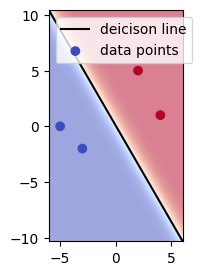

In [20]:
for i in range(1000):
    w = gradient_descent_step(y, X, w, learning_rate)

plot_decision_boundary(w)